# DATA 221 Project — Convolutional Neural Network (CNN) for Fruit Classification

## Objective
In this notebook, I will build and evaluate a Convolutional Neural Network (CNN) to classify four fruit categories: **Apple, Avocado, Banana, and Orange**.

This model is part of our DATA 221 group project, where multiple machine learning models are compared using the same dataset split. The goal of this notebook is to implement a CNN-based image classification pipeline, monitor model behavior during training, and evaluate whether the model generalizes well without severe overfitting.

The dataset used in this project comes from the **Fruits-360** dataset. The preprocessed dataset has already been prepared using the agreed project split:
- **Project_Train** for training
- **Project_Val** for validation
- **Project_Test** for final evaluation

This notebook will:
1. load the preprocessed image data,
2. verify that the data is correct,
3. build a CNN model,
4. train and monitor the model,
5. evaluate performance using accuracy, precision, recall, F1-score, and confusion matrix,
6. check for overfitting and improve the model if necessary.

## Step 1 — Import required libraries

In this step, I imported the libraries needed for the CNN workflow.

- `numpy` is used for working with image arrays.
- `matplotlib` and `seaborn` are used for visualization.
- `sklearn.metrics` is used to evaluate classification performance.
- `tensorflow.keras` is used to build, train, and evaluate the CNN model.

This step prepares the notebook environment before loading the preprocessed dataset.

In [3]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

## Step 2 — Define dataset paths and class names

In this step, I defined the folder paths for the shared project dataset created during preprocessing.

The preprocessing notebook already prepared three folders:
- `Project_Train`
- `Project_Val`
- `Project_Test`

Each of these folders contains one subfolder per final class:
- Apple
- Banana
- Avocado
- Orange

Using these folders ensures that this CNN notebook uses exactly the same project split that was prepared earlier for fair model comparison.

In [5]:
DATASET_ROOT = Path("fruits-360")

PROJECT_TRAIN_DIR = DATASET_ROOT/"Project_Train"
PROJECT_VAL_DIR   = DATASET_ROOT/"Project_Val"
PROJECT_TEST_DIR  = DATASET_ROOT/"Project_Test"

CLASS_NAMES = ["Apple", "Banana", "Avocado", "Orange"]
IMG_SIZE = (100, 100)

print("Project train dir:", PROJECT_TRAIN_DIR)
print("Project val dir  :", PROJECT_VAL_DIR)
print("Project test dir :", PROJECT_TEST_DIR)
print("Class names      :", CLASS_NAMES)
print("Image size       :", IMG_SIZE)

Project train dir: fruits-360/Project_Train
Project val dir  : fruits-360/Project_Val
Project test dir : fruits-360/Project_Test
Class names      : ['Apple', 'Banana', 'Avocado', 'Orange']
Image size       : (100, 100)


## Step 3 — Verify that the dataset folders exist

Before loading any images, I checked that the project dataset folders and class subfolders exist.

This is an important sanity check because the CNN notebook depends on the preprocessing notebook having already created the shared train, validation, and test directories correctly.

### Why this check matters

If any required folder is missing, the CNN model cannot be trained correctly.

By checking the folder structure first, I can confirm that:
- the preprocessing step was completed successfully,
- the four class folders exist in each split,
- and the CNN notebook is using the intended dataset organization.

In [7]:
for split_name, split_directory in {
    "Train": PROJECT_TRAIN_DIR,
    "Validation": PROJECT_VAL_DIR,
    "Test": PROJECT_TEST_DIR
}.items():
    print(f"\n{split_name} folder exists:", split_directory.exists())
    
    for class_name in CLASS_NAMES:
        class_dir = split_directory / class_name
        print(f"  {class_name}: {class_dir.exists()} -> {class_dir}")


Train folder exists: True
  Apple: True -> fruits-360/Project_Train/Apple
  Banana: True -> fruits-360/Project_Train/Banana
  Avocado: True -> fruits-360/Project_Train/Avocado
  Orange: True -> fruits-360/Project_Train/Orange

Validation folder exists: True
  Apple: True -> fruits-360/Project_Val/Apple
  Banana: True -> fruits-360/Project_Val/Banana
  Avocado: True -> fruits-360/Project_Val/Avocado
  Orange: True -> fruits-360/Project_Val/Orange

Test folder exists: True
  Apple: True -> fruits-360/Project_Test/Apple
  Banana: True -> fruits-360/Project_Test/Banana
  Avocado: True -> fruits-360/Project_Test/Avocado
  Orange: True -> fruits-360/Project_Test/Orange


## Step 4 — Count images in each dataset split

In this step, I count how many images belong to each class in the training, validation, and test folders.

This check is important because it confirms that:
- All 4 classes are present in each split,
- The class distribution is reasonable,
- No class is missing or severely underrepresented.

A balanced class distribution helps make the CNN evaluation more reliable and easier to interpret.

### Interpretation

These counts show how the dataset is distributed across the training, validation, and test splits.

At this stage, I expect:
- All classes to appear in every split,
- Training to contain the largest number of images,
- Validation to be smaller than training,
- The official test split to remain separate for final evaluation only.

If the class counts are close to balanced, that is a good sign for fair model training and evaluation.

In [8]:
def count_images_in_split(split_dir, class_names):
    counts = {}
    for class_name in class_names:
        class_dir = split_dir / class_name
        image_files = [p for p in class_dir.iterdir() if p.is_file()]
        counts[class_name] = len(image_files)
    return counts

train_counts = count_images_in_split(PROJECT_TRAIN_DIR, CLASS_NAMES)
val_counts   = count_images_in_split(PROJECT_VAL_DIR, CLASS_NAMES)
test_counts  = count_images_in_split(PROJECT_TEST_DIR, CLASS_NAMES)

print("Training counts:")
for k, v in train_counts.items():
    print(f"  {k}: {v}")

print("\nValidation counts:")
for k, v in val_counts.items():
    print(f"  {k}: {v}")

print("\nTest counts:")
for k, v in test_counts.items():
    print(f"  {k}: {v}")

Training counts:
  Apple: 830
  Banana: 830
  Avocado: 831
  Orange: 830

Validation counts:
  Apple: 147
  Banana: 147
  Avocado: 146
  Orange: 147

Test counts:
  Apple: 327
  Banana: 327
  Avocado: 327
  Orange: 327


In [10]:
print("Total training images  :", sum(train_counts.values()))
print("Total validation images:", sum(val_counts.values()))
print("Total test images      :", sum(test_counts.values()))

Total training images  : 3321
Total validation images: 587
Total test images      : 1308


## Step 5 — Visual inspection of sample images

Before training the CNN, I visually inspect a few images from each dataset split.

This helps confirm that:
- The images are readable,
- The class folders contain the expected fruit images,
- The preprocessing split was created correctly,
- There are no obvious issues such as wrong labels, corrupted files, or unexpected image content.

Visual inspection is especially helpful in image classification tasks because some problems can only be detected by actually looking at the images.

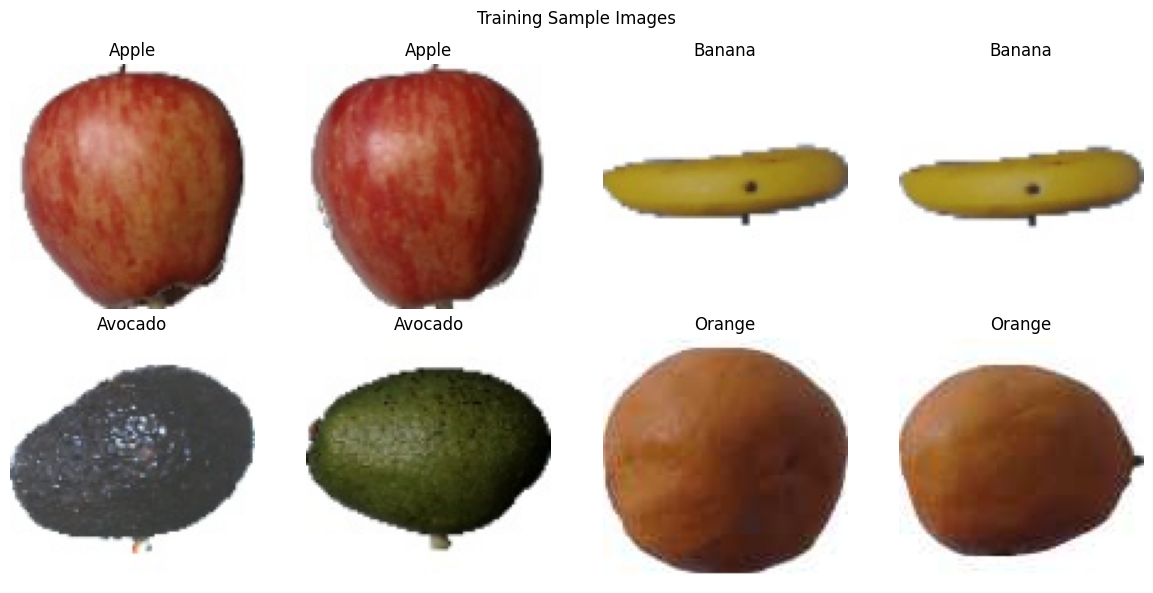

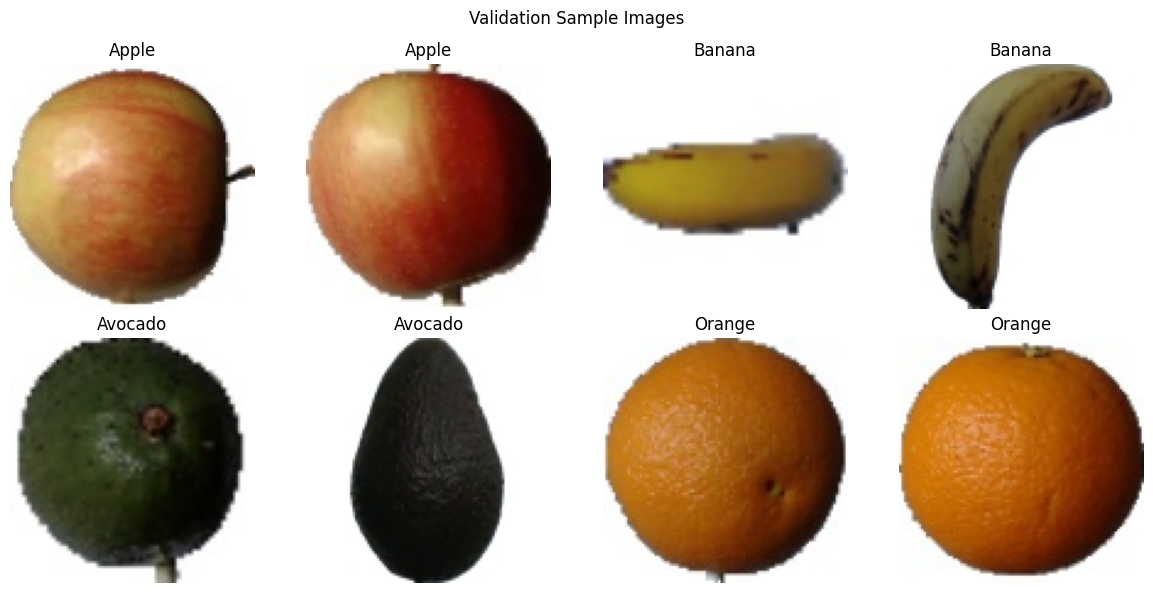

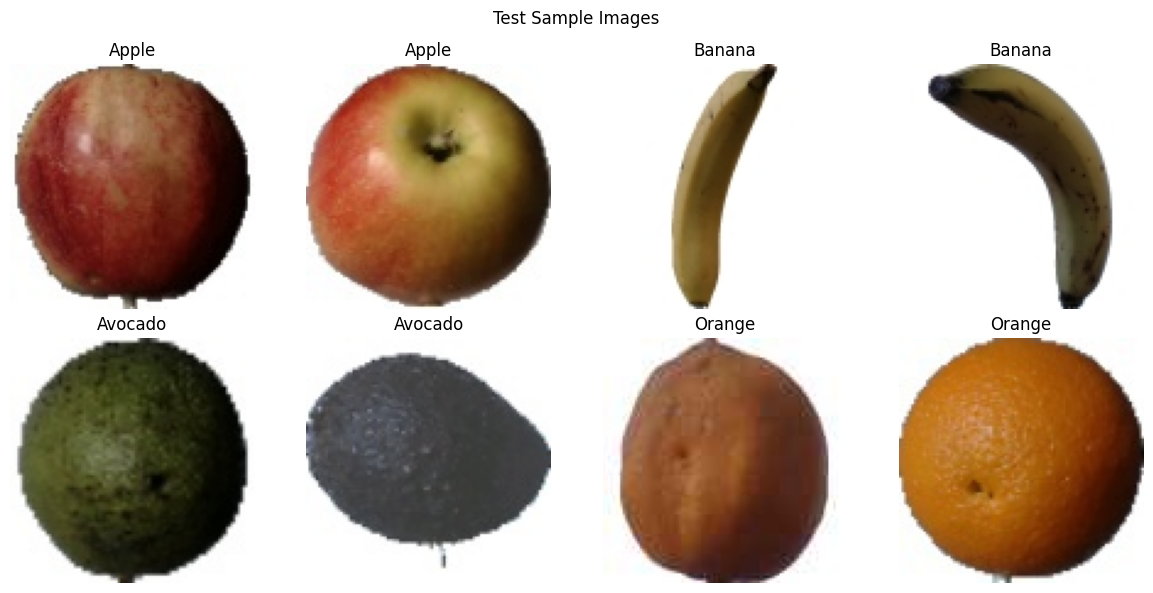

In [12]:
import random
import cv2

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def load_sample_images(split_dir, class_names, img_size=(100, 100), num_per_class=2):
    samples = []

    for class_name in class_names:
        class_dir = split_dir / class_name
        image_files = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS]

        chosen_files = random.sample(image_files, min(num_per_class, len(image_files)))

        for file_path in chosen_files:
            img = cv2.imread(str(file_path))
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, img_size)
            samples.append((class_name, img_resized))

    return samples

train_samples = load_sample_images(PROJECT_TRAIN_DIR, CLASS_NAMES, img_size=IMG_SIZE, num_per_class=2)
val_samples   = load_sample_images(PROJECT_VAL_DIR, CLASS_NAMES, img_size=IMG_SIZE, num_per_class=2)
test_samples  = load_sample_images(PROJECT_TEST_DIR, CLASS_NAMES, img_size=IMG_SIZE, num_per_class=2)

def show_samples(samples, title):
    plt.figure(figsize=(12, 6))
    for i, (label, image) in enumerate(samples):
        plt.subplot(2, 4, i + 1)
        plt.imshow(image)
        plt.title(label)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_samples, "Training Sample Images")
show_samples(val_samples, "Validation Sample Images")
show_samples(test_samples, "Test Sample Images")

## Step 6 — Load all images into arrays

In this step, I load all images from the training, validation, and test folders into NumPy arrays.

This conversion is necessary because the CNN model cannot train directly from image files in folders. Instead, the images must be:
- Read from disk,
- Resized to a fixed shape,
- Converted into numeric arrays,
- Paired with their class labels.

### Why this step matters

This step converts the folder-based dataset into a format that can be used by machine learning models.

At this point, I expect:
- the image arrays to have shape `(number_of_images, height, width, 3)`,
- the labels to appear as text class names,
- and the number of loaded images to match the counts checked earlier.

If the shapes and labels look correct, then the dataset is ready for normalization and label encoding.


In [15]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def load_images_from_folder(folder_path, class_names, img_size=(100, 100)):
    images = []
    labels = []

    for class_name in class_names:
        class_folder = folder_path / class_name

        for file_path in class_folder.iterdir():
            if not file_path.is_file():
                continue
            if file_path.suffix.lower() not in VALID_EXTENSIONS:
                continue

            img = cv2.imread(str(file_path))
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, img_size)

            images.append(img_resized)
            labels.append(class_name)

    return np.array(images), np.array(labels)

X_train, y_train_text = load_images_from_folder(PROJECT_TRAIN_DIR, CLASS_NAMES, img_size=IMG_SIZE)
X_val, y_val_text     = load_images_from_folder(PROJECT_VAL_DIR, CLASS_NAMES, img_size=IMG_SIZE)
X_test, y_test_text   = load_images_from_folder(PROJECT_TEST_DIR, CLASS_NAMES, img_size=IMG_SIZE)

print("Images loaded successfully.")

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("\nFirst few training labels:", y_train_text[:10])
print("First few validation labels:", y_val_text[:10])
print("First few test labels:", y_test_text[:10])

Images loaded successfully.
X_train shape: (3321, 100, 100, 3)
X_val shape  : (587, 100, 100, 3)
X_test shape : (1308, 100, 100, 3)

First few training labels: ['Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple'
 'Apple']
First few validation labels: ['Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple'
 'Apple']
First few test labels: ['Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple'
 'Apple']


## Step 7 — Normalize images and encode labels

In this step, I prepare the loaded image arrays and labels for CNN training.

Two tasks are performed here:

1. **Normalize pixel values**  
   The image arrays currently contain pixel values between 0 and 255.  
   I scale them to the range `[0, 1]` by dividing by 255. This helps the CNN train more efficiently and more stably.

2. **Encode class labels**  
   The class labels are currently stored as text values such as `Apple`, `Banana`, `Avocado`, and `Orange`.  
   Since the CNN requires numeric target labels, I first convert them to integer labels and then convert those integers into one-hot encoded vectors.

This step ensures that the dataset is in the correct numerical format for multi-class image classification.

In [16]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Normalize image pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print("Train min/max:", X_train.min(), X_train.max())
print("Val min/max  :", X_val.min(), X_val.max())
print("Test min/max :", X_test.min(), X_test.max())

label_encoder = LabelEncoder()

y_train_int = label_encoder.fit_transform(y_train_text)
y_val_int   = label_encoder.transform(y_val_text)
y_test_int  = label_encoder.transform(y_test_text)

y_train = to_categorical(y_train_int)
y_val   = to_categorical(y_val_int)
y_test  = to_categorical(y_test_int)

print("Encoded classes:", list(label_encoder.classes_))
print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

print("Sample integer labels (train):", y_train_int[:12])
print("Sample one-hot labels (train):")
print(y_train[:5])

Train min/max: 0.0 1.0
Val min/max  : 0.0 1.0
Test min/max : 0.0 1.0
Encoded classes: [np.str_('Apple'), np.str_('Avocado'), np.str_('Banana'), np.str_('Orange')]
y_train shape: (3321, 4)
y_val shape  : (587, 4)
y_test shape : (1308, 4)
Sample integer labels (train): [0 0 0 0 0 0 0 0 0 0 0 0]
Sample one-hot labels (train):
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


### Interpretation of normalization and label encoding

The normalization step worked correctly because the minimum pixel value is 0.0 and the maximum pixel value is 1.0 for the training, validation, and test sets.

The label encoding step also worked correctly. The `LabelEncoder` sorted the class names alphabetically, so the final class-to-integer mapping is:

- Apple → 0
- Avocado → 1
- Banana → 2
- Orange → 3

The first few training labels are all encoded as 0 because the images were loaded class-by-class, and the Apple class appears first in the loaded training data.

The one-hot vectors are also correct. For example, the vector `[1. 0. 0. 0.]` represents the Apple class.

## Step 8 — Shuffle the dataset

At this point, the images are still ordered by class because they were loaded folder-by-folder.

Before training the CNN, I shuffle the training and validation sets so that the model sees a mixed order of classes during learning. This is important because training on class-ordered data can negatively affect learning behavior.

The test set will not be shuffled here because it is only used for final evaluation.

In [17]:
from sklearn.utils import shuffle

X_train, y_train, y_train_int = shuffle(X_train, y_train, y_train_int, random_state=42)
X_val, y_val, y_val_int = shuffle(X_val, y_val, y_val_int, random_state=42)

print("Training and validation sets shuffled successfully.")

print("Sample shuffled integer labels (train):", y_train_int[:12])
print("Sample shuffled integer labels (val)  :", y_val_int[:12])

Training and validation sets shuffled successfully.
Sample shuffled integer labels (train): [2 0 3 0 2 3 0 1 3 2 2 3]
Sample shuffled integer labels (val)  : [3 2 3 1 2 0 1 2 3 0 3 0]


### Interpretation of shuffling

After shuffling, the label order should appear mixed rather than being grouped by class.

This is a useful final preparation step before training because it ensures that the CNN is exposed to a more natural mixture of classes during optimization.

## Step 9 — Build a baseline CNN model

In this step, I build a baseline Convolutional Neural Network (CNN) for fruit classification.

The purpose of this first model is to create a simple starting point before applying more advanced improvements. A baseline model is useful because it helps reveal whether the current dataset and architecture are already sufficient, or whether the model begins to overfit.

This CNN uses:
- convolution layers to learn image features,
- max pooling to reduce spatial size,
- dropout to reduce overfitting,
- and a final softmax output layer for four-class classification.

I will start with a relatively simple architecture and then evaluate its training and validation behavior before deciding whether improvements are needed.

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

### Why data augmentation is included

The Fruits-360 dataset contains clean fruit images with simple backgrounds, so there is a risk that the model may memorize patterns too easily.

To help reduce overfitting, I apply light data augmentation during training:
- horizontal flipping,
- small rotation,
- and small zoom changes.

These transformations are only applied during training and help the model become less sensitive to small visual variations.

In [24]:
baseline_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(4, activation="softmax")
])

baseline_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,188 (9.36 MB)

 Trainable params: 2,453,188 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
baseline_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(4, activation="softmax")
])

baseline_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

### Interpretation of the baseline architecture

The initial CNN design produced a large number of parameters (over 2.4 million), mainly due to the use of a Flatten layer followed by a dense layer.

This could lead to overfitting because the model may memorize the training images instead of learning generalizable features.

To address this issue, I replaced the Flatten layer with GlobalAveragePooling2D. This significantly reduces the number of parameters and encourages the model to focus on high-level feature representations instead of individual pixel patterns. This adjustment helps improve generalization and reduces the risk of overfitting before training begins.

In the convolutional and dense layers, the ReLU and activation function is used. ReLU introduces non-linearity into the model, allowing it to learn complex patterns such as edges, textures, and shapes in fruit images. It is also computationally efficient and helps mitigate the vanishing gradient problem, making training more stable.

In the output layer, the Softmax activation function is used because this is a multi-class classification problem with four fruit categories (Apple, Banana, Avocado, Orange). Softmax converts the model’s outputs into a probability distribution, where each value represents the likelihood of the image belonging to a specific class, and all probabilities sum to 1. This allows the model to make clear and interpretable predictions.

## Step 10 — Compile the CNN model

Before training, the CNN model must be compiled.

Compiling the model defines:
- the **optimizer**, which controls how the model updates its weights,
- the **loss function**, which measures prediction error,
- and the **evaluation metric**, which tracks model performance during training.

For this multi-class fruit classification problem:
- I use the **Adam** optimizer because it is widely used and works well for deep learning tasks,
- I use **categorical cross-entropy** as the loss function because the target labels are one-hot encoded,
- and I track **accuracy** as the main training metric.

In [27]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Step 11 — Train the CNN model

In this step, the compiled CNN model is trained using the prepared training and validation datasets.

The model is trained for a maximum of 15 epochs with a batch size of 32. During training, the model learns visual patterns from the fruit images and adjusts its weights to improve classification performance.

To reduce the risk of overfitting, I use **EarlyStopping**. This monitors the validation loss during training and stops training early if the model stops improving. The best model weights are also restored automatically.

The training dataset is used to update the model weights, while the validation dataset is used to monitor how well the model generalizes during training.

The main values to monitor are:
- **training loss**
- **validation loss**
- **training accuracy**
- **validation accuracy**

These results will later be used to determine whether the model is learning effectively or beginning to overfit.

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - accuracy: 0.6260 - loss: 0.7698 - val_accuracy: 0.8194 - val_loss: 0.3238
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - accuracy: 0.8410 - loss: 0.3479 - val_accuracy: 0.9710 - val_loss: 0.1594
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.9539 - loss: 0.1378 - val_accuracy: 0.9864 - val_loss: 0.0451
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.9858 - loss: 0.0496 - val_accuracy: 0.9966 - val_loss: 0.0313
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.9780 - loss: 0.0652 - val_accuracy: 1.0000 - val_loss: 0.0137
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.9949 - loss: 0.0180 - val_accuracy: 0.9949 - val_loss: 0.0135
Epoch 7/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 154ms/step - accuracy: 0.9979 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 0.0124
Epoch 8/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 155ms/step - accuracy: 0.9886 - loss: 0

### Interpretation of training results

The baseline CNN trained successfully and showed strong performance on both the training and validation sets.

Overall, the model does not currently show a classic overfitting pattern. In a typical overfitting case, training accuracy would continue improving while validation accuracy would stagnate or decrease, and validation loss would increase. That pattern is not clearly visible here.

Instead, both training and validation performance improved substantially across epochs, and validation loss remained very low for most of training. This suggests that the model is learning the task effectively.

However, the validation accuracy reached 1.0000 multiple times, which is unusually high. Since the Fruits-360 dataset contains very clean fruit images with simple white backgrounds, this may indicate that the task is relatively easy for the model. It does not automatically imply data leakage, but it does mean that final test-set evaluation is especially important.

The next step is to examine the training curves and evaluate the model on the held-out test set to determine whether this strong validation performance also generalizes to unseen data.

## Step 12 — Plot training and validation curves

In this step, I visualize the training and validation accuracy and loss across epochs.

These plots are important because they provide a clearer view of the model’s learning behavior than the training log alone. In particular, they help identify whether:
- the model is learning effectively,
- the validation performance follows the training performance,
- or the model begins to overfit.

If the training and validation curves improve together and remain reasonably close, that is generally a good sign. If training performance keeps improving while validation performance gets worse, that would suggest overfitting.

These plots will be used to assess whether the current CNN model is stable enough for final evaluation on the test set.

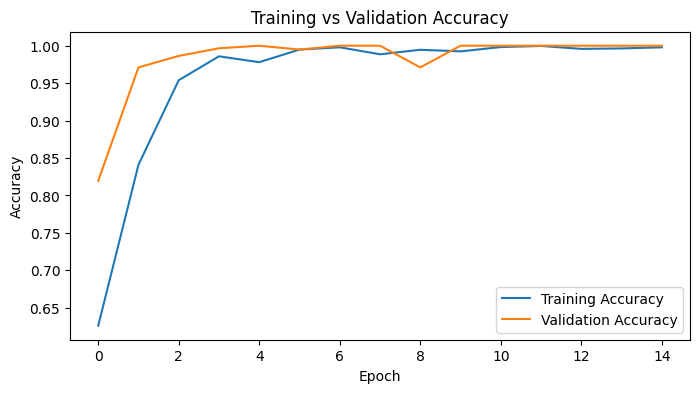

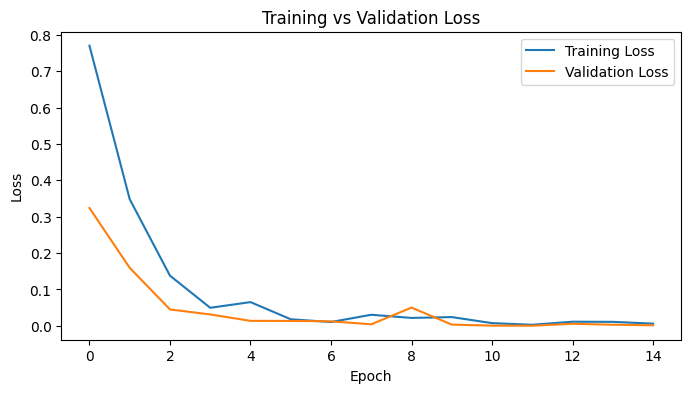

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Interpretation of learning curves

The training and validation curves show that the CNN model is learning effectively and consistently.

From the accuracy plot, both training and validation accuracy increase rapidly during the first few epochs and quickly reach very high values close to 1.0. The two curves remain very close to each other throughout training, which indicates that the model is generalizing well to unseen validation data.

From the loss plot, both training and validation loss decrease sharply and remain low. There is no sustained increase in validation loss while training loss continues to decrease, which would typically indicate overfitting. Although there are small fluctuations (e.g., around epoch 8), the overall trend remains stable.

Overall, the model does not exhibit clear signs of overfitting. Instead, it shows strong and stable learning behavior. However, the near-perfect validation accuracy suggests that the dataset may be relatively simple, as the images have clean backgrounds and limited variation.

Therefore, it is important to evaluate the model on the independent test set to confirm whether this high performance generalizes to completely unseen data.

## Step 13 — Evaluate on the test set

In this step, the trained CNN model is evaluated on the test dataset.

The test set was not used during training or validation, so it provides an unbiased measure of the model’s performance on completely unseen data.

The same evaluation metrics (accuracy, precision, recall, and F1-score) will be used to assess how well the model generalizes.

This step is critical to confirm whether the high validation performance reflects true model capability or is influenced by the simplicity of the dataset.

In [31]:
from sklearn.metrics import classification_report

test_loss, test_accuracy = baseline_model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

y_pred = baseline_model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test.argmax(axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 1.0000 - loss: 1.3780e-04
Test Loss: 0.0001378010056214407
Test Accuracy: 1.0
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

Classification Report:
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       327
      Banana       1.00      1.00      1.00       327
     Avocado       1.00      1.00      1.00       327
      Orange       1.00      1.00      1.00       327

    accuracy                           1.00      1308
   macro avg       1.00      1.00      1.00      1308
weighted avg       1.00      1.00      1.00      1308



### Test set evaluation and interpretation

The CNN model achieved perfect performance on the test set, with an accuracy of 1.00 and precision, recall, and F1-score of 1.00 for all classes.

While this indicates that the model is able to classify the fruit images correctly, such perfect performance is unusual in real-world machine learning problems. This suggests that the dataset may be relatively simple rather than the model being universally robust.

The Fruits-360 dataset consists of images with clean white backgrounds, consistent lighting, and limited variation in object positioning. As a result, the model can easily learn distinguishing visual features, leading to near-perfect classification performance.

Therefore, although the model performs extremely well on this dataset, its performance may not generalize as effectively to real-world images where lighting, background, and orientation vary significantly.

To better evaluate real-world performance, additional testing using more diverse images (e.g., webcam input or images with complex backgrounds) would be necessary.